In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [8]:
nav=pd.read_csv("C:/Users/user/OneDrive/Desktop/bluestock_mf_capstone/data/raw data/02_nav_history.csv")
benchmark=pd.read_csv("C:/Users/user/OneDrive/Desktop/bluestock_mf_capstone/data/raw data/10_benchmark_indices.csv")

In [9]:
nav

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692
...,...,...,...
45995,149324,2026-05-25,292.4810
45996,149324,2026-05-26,291.2707
45997,149324,2026-05-27,288.8007
45998,149324,2026-05-28,280.6873


In [11]:
benchmark

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15
...,...,...,...
8045,2026-05-25,CRISIL_GILT,2278.26
8046,2026-05-26,CRISIL_GILT,2281.42
8047,2026-05-27,CRISIL_GILT,2281.30
8048,2026-05-28,CRISIL_GILT,2298.35


In [28]:
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

nav = nav.sort_values(['amfi_code', 'date'])

benchmark = benchmark.sort_values(['index_name', 'date'])
print(nav.head())
print(benchmark.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
           date    index_name  close_value
3450 2022-01-03  BSE_SMALLCAP     26554.60
3451 2022-01-04  BSE_SMALLCAP     27079.92
3452 2022-01-05  BSE_SMALLCAP     27313.35
3453 2022-01-06  BSE_SMALLCAP     27377.05
3454 2022-01-07  BSE_SMALLCAP     26316.86


In [27]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

print(nav.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


In [29]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

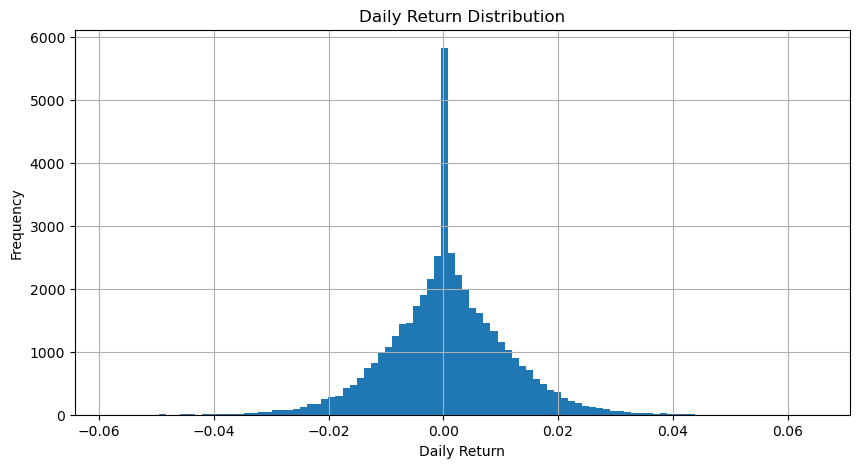

In [30]:
plt.figure(figsize=(10,5))

nav['daily_return'].hist(
    bins=100
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [31]:
# ================================
# CAGR FUNCTION
# ================================

def calculate_cagr(df, years):

    end_date = df['date'].max()

    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df['date'] >= start_date]

    if len(temp) < 2:
        return np.nan

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    return cagr

In [32]:
# ================================
# CAGR TABLE
# ================================

cagr_table = []

for code, group in nav.groupby('amfi_code'):

    row = {
        'amfi_code': code,

        'CAGR_1Y': calculate_cagr(group, 1),

        'CAGR_3Y': calculate_cagr(group, 3),

        'CAGR_5Y': calculate_cagr(group, 5)
    }

    cagr_table.append(row)

cagr_df = pd.DataFrame(cagr_table)

print(cagr_df.head())

   amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y
0     100016 -0.022243  0.012926  0.023168
1     100025  0.037050  0.039164  0.039127
2     100033  0.532324  0.324425  0.260741
3     101206  0.479241  0.289677  0.204427
4     101207 -0.239860 -0.041524  0.069533


In [33]:
# ================================
# SHARPE RATIO
# ================================

RF = 0.065

sharpe_list = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    annual_return = (
        returns.mean() * 252
    )

    annual_std = (
        returns.std() * np.sqrt(252)
    )

    sharpe = (
        (annual_return - RF)
        / annual_std
    )

    sharpe_list.append({
        'amfi_code': code,
        'sharpe_ratio': sharpe
    })

sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
)

print(sharpe_df.head())

    amfi_code  sharpe_ratio
34     148567      1.448291
30     120843      1.306744
36     148569      1.234930
19     119551      1.208267
25     120505      1.180101


In [34]:
# ================================
# SORTINO RATIO
# ================================

sortino_list = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    downside = returns[returns < 0]

    downside_std = (
        downside.std() * np.sqrt(252)
    )

    annual_return = (
        returns.mean() * 252
    )

    sortino = (
        (annual_return - RF)
        / downside_std
    )

    sortino_list.append({
        'amfi_code': code,
        'sortino_ratio': sortino
    })

sortino_df = pd.DataFrame(sortino_list)

print(sortino_df.head())

   amfi_code  sortino_ratio
0     100016      -0.351047
1     100025      -0.941821
2     100033       1.829134
3     101206       1.799563
4     101207       0.276644


In [35]:
# ================================
# NIFTY100 BENCHMARK
# ================================

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [36]:
# ================================
# ALPHA AND BETA
# ================================

alpha_beta_list = []

for code, group in nav.groupby('amfi_code'):

    merged = pd.merge(
        group,
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, se = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_list.append({
        'amfi_code': code,
        'alpha': alpha,
        'beta': beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_list)

print(alpha_beta_df.head())

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


In [37]:
# ================================
# MAXIMUM DRAWDOWN
# ================================

drawdown_list = []

for code, group in nav.groupby('amfi_code'):

    group = group.sort_values('date')

    running_max = (
        group['nav']
        .cummax()
    )

    drawdown = (
        group['nav'] / running_max
    ) - 1

    max_dd = drawdown.min()

    worst_idx = drawdown.idxmin()

    worst_date = group.loc[
        worst_idx,
        'date'
    ]

    drawdown_list.append({
        'amfi_code': code,
        'max_drawdown': max_dd,
        'worst_drawdown_date': worst_date
    })

drawdown_df = pd.DataFrame(drawdown_list)

print(drawdown_df.head())

   amfi_code  max_drawdown worst_drawdown_date
0     100016     -0.247344          2022-09-15
1     100025     -0.043083          2023-07-28
2     100033     -0.162172          2022-05-12
3     101206     -0.112916          2023-07-05
4     101207     -0.354469          2026-05-11


In [38]:
# ================================
# FUND SCORECARD
# ================================

scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code'
)

# Rankings

scorecard['return_rank'] = (
    scorecard['CAGR_3Y']
    .rank(pct=True)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(pct=True)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(pct=True)
)

scorecard['dd_rank'] = (
    (-scorecard['max_drawdown'])
    .rank(pct=True)
)

# FINAL SCORE

scorecard['fund_score'] = (
    30 * scorecard['return_rank']
    + 25 * scorecard['sharpe_rank']
    + 20 * scorecard['alpha_rank']
    + 10 * scorecard['dd_rank']
)

scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)

print(scorecard.head())

    amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y  sharpe_ratio     alpha      beta  \
25     120505  0.296047  0.317775  0.283768      1.180101  0.292636  0.000549   
34     148567  0.203607  0.340009  0.267993      1.448291  0.269838  0.023684   
36     148569  0.397518  0.291789  0.276299      1.234930  0.282704  0.018134   
16     119094  0.222611  0.351118  0.244453      0.998231  0.260767 -0.066265   
2      100033  0.532324  0.324425  0.260741      1.093699  0.271954  0.005104   

    max_drawdown worst_drawdown_date  return_rank  sharpe_rank  alpha_rank  \
25     -0.181885          2025-01-23        0.900         0.90       0.950   
34     -0.112657          2023-10-20        0.975         1.00       0.850   
36     -0.163967          2023-10-20        0.825         0.95       0.925   
16     -0.209609          2022-08-11        1.000         0.75       0.800   
2      -0.162172          2022-05-12        0.925         0.85       0.875   

    dd_rank  fund_score  
25    0.625       

In [39]:
# ================================
# TRACKING ERROR
# ================================

tracking_error_list = []

for code, group in nav.groupby('amfi_code'):

    merged = pd.merge(
        group,
        nifty100[['date', 'benchmark_return']],
        on='date'
    )

    merged = merged.dropna()

    diff = (
        merged['daily_return']
        - merged['benchmark_return']
    )

    tracking_error = (
        diff.std()
        * np.sqrt(252)
    )

    tracking_error_list.append({
        'amfi_code': code,
        'tracking_error': tracking_error
    })

tracking_df = pd.DataFrame(
    tracking_error_list
)

print(tracking_df.head())

   amfi_code  tracking_error
0     100016        0.199284
1     100025        0.134535
2     100033        0.228699
3     101206        0.192706
4     101207        0.292117


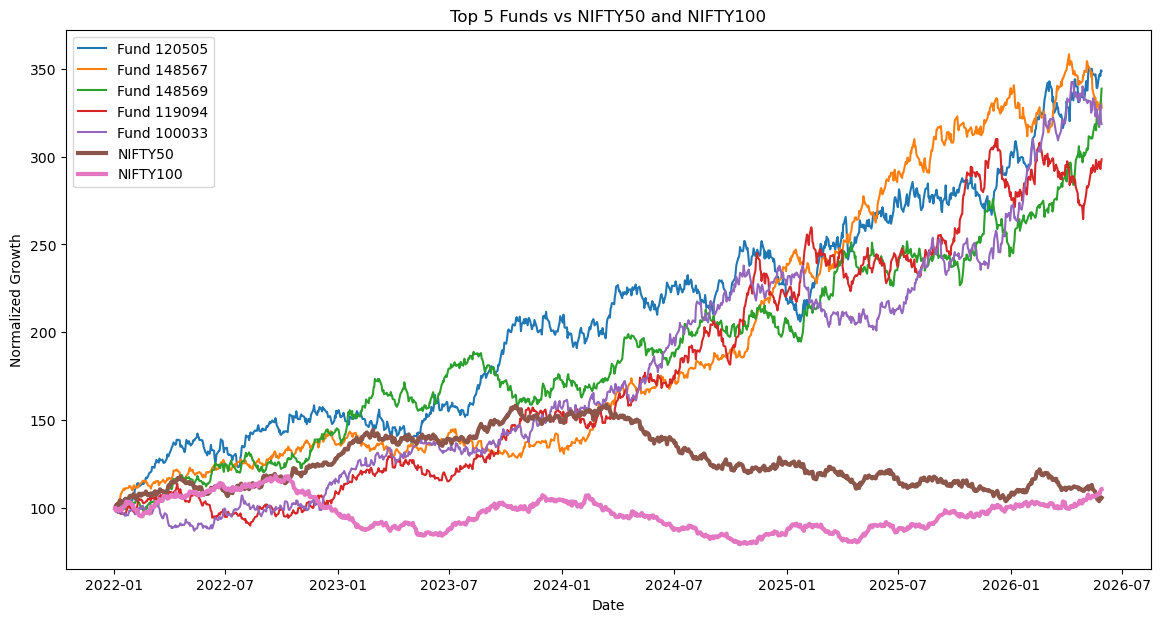

In [40]:
# ================================
# TOP 5 FUNDS VS BENCHMARK
# ================================

top5 = (
    scorecard
    .sort_values(
        'fund_score',
        ascending=False
    )
    .head(5)
)

plt.figure(figsize=(14,7))

for code in top5['amfi_code']:

    temp = nav[
        nav['amfi_code'] == code
    ]

    temp = temp.sort_values('date')

    normalized = (
        temp['nav']
        / temp['nav'].iloc[0]
    ) * 100

    plt.plot(
        temp['date'],
        normalized,
        label=f'Fund {code}'
    )

# NIFTY50

nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty50 = nifty50.sort_values('date')

nifty50_norm = (
    nifty50['close_value']
    / nifty50['close_value'].iloc[0]
) * 100

plt.plot(
    nifty50['date'],
    nifty50_norm,
    linewidth=3,
    label='NIFTY50'
)

# NIFTY100

nifty100_norm = (
    nifty100['close_value']
    / nifty100['close_value'].iloc[0]
) * 100

plt.plot(
    nifty100['date'],
    nifty100_norm,
    linewidth=3,
    label='NIFTY100'
)

plt.title(
    'Top 5 Funds vs NIFTY50 and NIFTY100'
)

plt.xlabel('Date')

plt.ylabel('Normalized Growth')

plt.legend()

plt.show()